In [1]:
# Verify library versions
import tdt
import neurokit2 as nk
from neurokit2 import signal_filter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import signal_processing as sp
import importlib

print("TDT version:", tdt.__version__)
print("NeuroKit2 version:", nk.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

TDT version: 0.6.6
NeuroKit2 version: 0.2.10
NumPy version: 1.26.4
Pandas version: 2.2.3
Matplotlib version: 3.10.0


In [2]:
tdt_path = r"E:\resp_test_data\subj11-250227-071133"

mouse = tdt.read_block(tdt_path)

print(mouse)

Found Synapse note file: E:\resp_test_data\subj11-250227-071133\Notes.txt
read from t=0s to t=308.64s
epocs	[struct]
snips	[struct]
streams	[struct]
scalars	[struct]
info	[struct]
time_ranges:	array([[ 0.],
       [inf]])


In [3]:
# Taking array of 'Resp' Attributes
resp_stream = mouse.streams['Resp']

# Extract key attributes
resp_data = resp_stream.data
fs = resp_stream.fs
start_time = resp_stream.start_time
data_shape = resp_stream.data.shape
size = resp_data.shape[0]
channel = resp_stream.channel
stream_name = resp_stream.name

In [4]:
print(f"Sampling frequency (fs): {fs}")
print(f"Size: {size}")

# Compute total duration in seconds
total_duration = size / fs  

# Convert to minutes
total_duration_minutes = total_duration / 60  

print(f"Total duration of respiratory data: {total_duration} seconds ({total_duration_minutes} minutes)")

Sampling frequency (fs): 305.17578125
Size: 94144
Total duration of respiratory data: 308.4910592 seconds (5.1415176533333335 minutes)


In [5]:
# Apply the custom filtering logic
rsp_cleaned = nk.signal_filter(
    resp_data,
    lowcut=0.1,   # Low cutoff frequency (Hz)
    highcut=20,   # High cutoff frequency (Hz)
    method="butterworth",  # Filtering method
    sampling_rate=fs,
    order=2  # Filter order
)

In [6]:
rsp_cleaned

array([-0.01761706, -0.02324762, -0.02888189, ...,  0.09195347,
        0.08209244,  0.0722134 ])

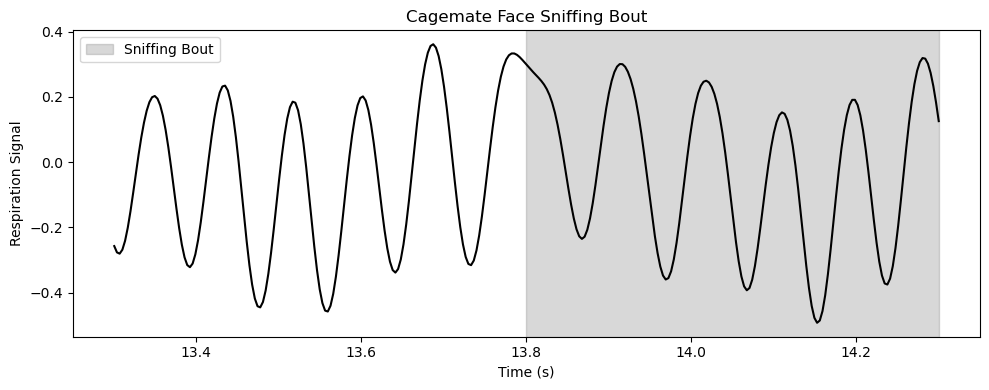

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 13.8  # Sniff bout start (seconds)
sniff_end = 13.8+0.5  # Sniff bout end (seconds)
window_start = sniff_start - .5  # 2 seconds before
window_end = sniff_start + .5  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Cagemate Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()

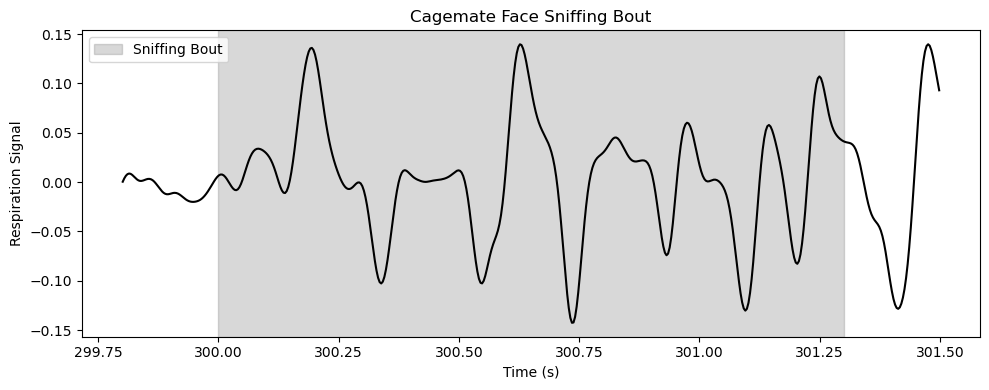

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 300  # Sniff bout start (seconds)
sniff_end = 301.3  # Sniff bout end (seconds)
window_start = sniff_start - .2  # 2 seconds before
window_end = sniff_end + .2  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Cagemate Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()

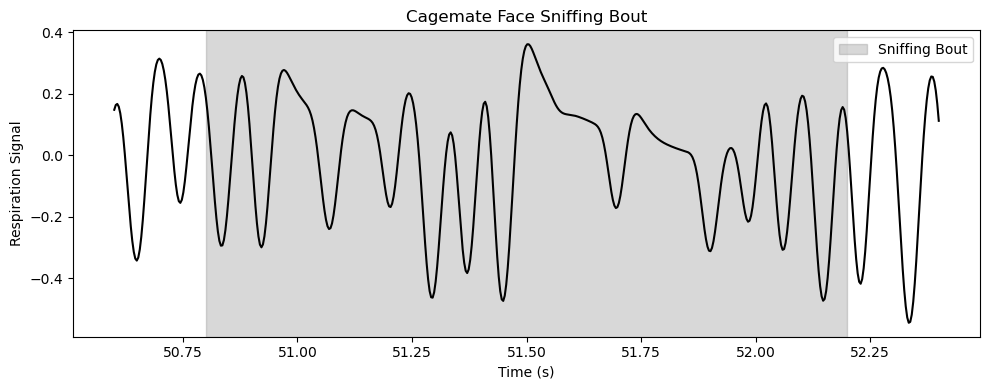

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 50.8  # Sniff bout start (seconds)
sniff_end = 52.2  # Sniff bout end (seconds)
window_start = sniff_start - .2  # 2 seconds before
window_end = sniff_end + .2  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Cagemate Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()

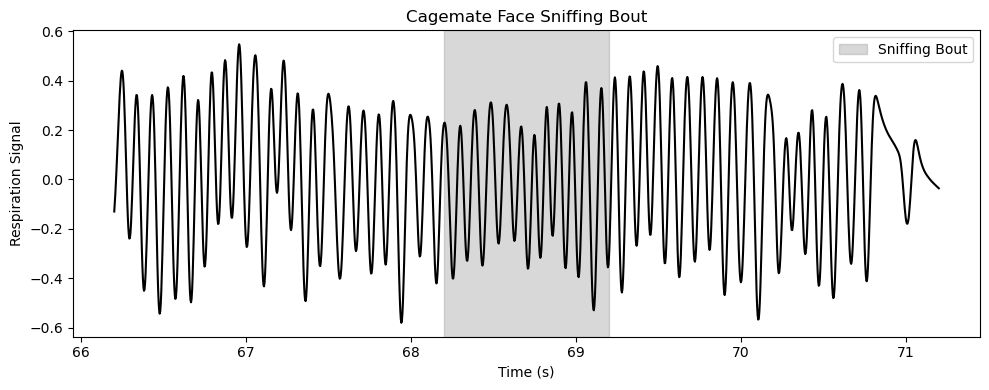

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 68.2  # Sniff bout start (seconds)
sniff_end = 69.2  # Sniff bout end (seconds)
window_start = sniff_start - 2  # 2 seconds before
window_end = sniff_end + 2  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Cagemate Face Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()

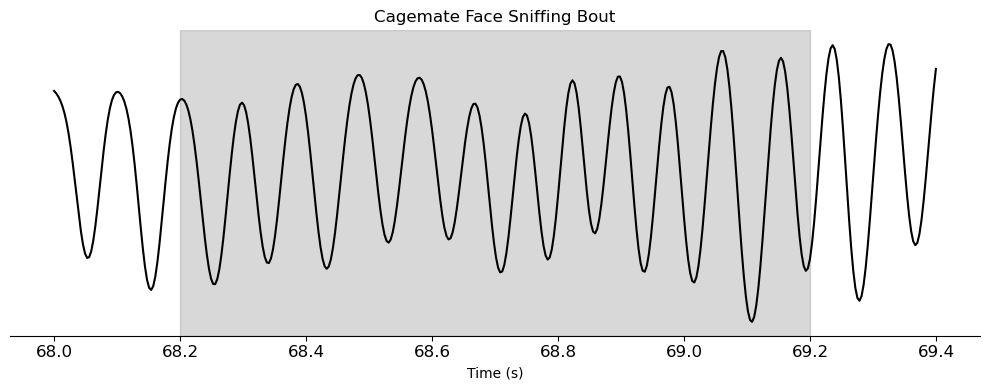

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 68.2  # Sniff bout start (seconds)
sniff_end = 69.2  # Sniff bout end (seconds)
window_start = sniff_start - 0.2  
window_end = sniff_end + 0.2  

# Create time array
time_array = np.arange(0, size) / fs + start_time  

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.xticks(fontsize=12)  # Keep absolute x-axis
plt.yticks([])  # Remove y-axis labels
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.title("Cagemate Face Sniffing Bout")



plt.grid(False)
plt.tight_layout()

# Show plot
plt.show()



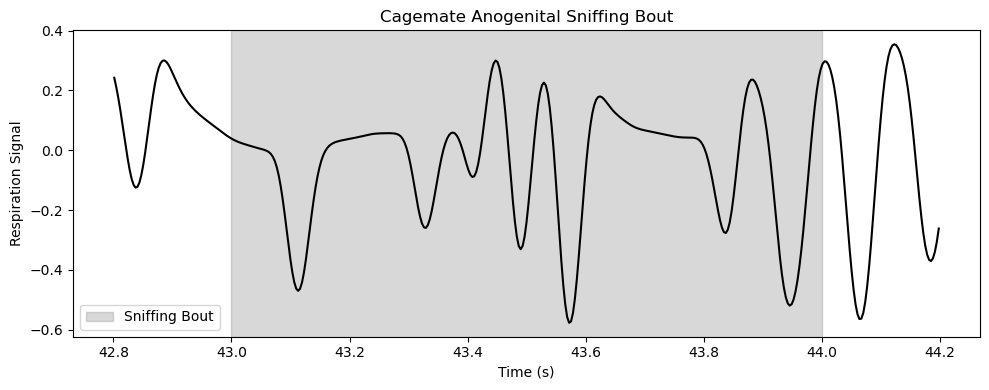

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Define time window
sniff_start = 43  # Sniff bout start (seconds)
sniff_end = 44  # Sniff bout end (seconds)
window_start = sniff_start - .2  # 2 seconds before
window_end = sniff_end + .2  # 2 seconds after

# Create time array
time_array = np.arange(0, size) / fs + start_time  # Convert indices to time

# Extract indices for the desired time window
start_idx = np.searchsorted(time_array, window_start)
end_idx = np.searchsorted(time_array, window_end)

# Subset the data
plot_time = time_array[start_idx:end_idx]
plot_resp = resp_data[start_idx:end_idx]

# Plot the respiratory signal
plt.figure(figsize=(10, 4))
plt.plot(plot_time, plot_resp, color='black', linewidth=1.5)

# Highlight the sniffing bout (2-7 sec) with a gray background
plt.axvspan(sniff_start, sniff_end, color='gray', alpha=0.3, label="Sniffing Bout")

# Formatting
plt.xlabel("Time (s)")
plt.ylabel("Respiration Signal")
plt.title("Cagemate Anogenital Sniffing Bout")
plt.legend()
plt.grid(False)  # Remove grid if not needed
plt.tight_layout()

# Show plot
plt.show()